# Motion conceptual space test


In [11]:
import os
import sys

sys.path.insert(0, os.path.abspath('../src'))


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from structures import ConceptMemory
from processors import MotionConceptExtractor
from utils.concepts import load_traj_exports

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'CMU Serif', 'DejaVu Serif'],
    'text.usetex': True,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
    'savefig.dpi': 300,
})


## Load exports


In [13]:
export_dir = Path('trajectory_exports')
manifest_path = export_dir / 'manifest.csv'

extractor = MotionConceptExtractor()
points = load_traj_exports(export_dir, manifest=manifest_path)
memory = ConceptMemory.from_points(extractor.space, points)

memory, memory.vectors.shape


(<ConceptMemory with 4 points in R^90>, (4, 90))

In [14]:
for point in memory:
    q = point.metadata.get('quality_summary', {})
    print(
        f"{point.metadata.get('object'):<5} "
        f"{point.label:<18} "
        f"usable={point.metadata.get('usable_pose'):<7} "
        f"estimated={q.get('estimated_pose_ratio', np.nan):.3f} "
        f"propagated={q.get('num_propagated_poses', np.nan)} "
        f"scene={point.metadata.get('scene_file')}"
    )


box   translation        usable=yes     estimated=nan propagated=nan scene=scene_crop_b=8_bt=0.5_pe=1_pose-transl_box.joblib
box   depth_translation  usable=yes     estimated=0.095 propagated=180 scene=scene_crop_b=8_bt=0.5_pe=1_pose-dtransl_box.joblib
boat  translation        usable=partial estimated=0.091 propagated=194 scene=scene_crop_b=8_bt=0.5_pe=1_pose-transl_boat.joblib
boat  rotation           usable=no      estimated=0.075 propagated=177 scene=scene_crop_b=8_bt=0.5_pe=1_pose-rot_boat.joblib


## Motion space


In [15]:
X = memory.vectors
labels = np.array(memory.labels)
objects = np.array([point.metadata.get('object', 'object') for point in memory])
usability = np.array([point.metadata.get('usable_pose', 'unknown') for point in memory])

mu = X.mean(axis=0)
sigma = X.std(axis=0)
sigma[sigma == 0] = 1.0
X_norm = (X - mu) / sigma

U, S, Vt = np.linalg.svd(X_norm, full_matrices=False)
proj = X_norm @ Vt[:2].T
explained = (S ** 2) / np.maximum(len(X_norm) - 1, 1)
explained = explained / explained.sum() if explained.sum() > 0 else explained

proj.shape, explained[:2]


((4, 2), array([     0.4912,     0.30664]))

In [16]:
def plot_motion_projection(memory, proj, explained, mask=None, title='Motion conceptual space'):
    if mask is None:
        mask = np.ones(len(memory.points), dtype=bool)

    motion_colors = {
        'translation': 'C0',
        'depth_translation': 'C1',
        'rotation': 'C3',
    }
    object_markers = {
        'box': 'o',
        'boat': 's',
        'ball': '^',
    }

    fig, ax = plt.subplots(figsize=(7, 5))

    for idx, point in enumerate(memory):
        if not mask[idx]:
            continue

        obj = point.metadata.get('object', 'object')
        usable = point.metadata.get('usable_pose', 'unknown')
        alpha = 1.0 if usable == 'yes' else 0.45
        edge = 'black' if usable == 'yes' else '0.55'

        ax.scatter(
            proj[idx, 0], proj[idx, 1],
            color=motion_colors.get(point.label, '0.4'),
            marker=object_markers.get(obj, 'o'),
            s=90,
            alpha=alpha,
            edgecolor=edge,
            linewidth=1,
        )
        ax.annotate(
            f'{obj} {point.label}',
            (proj[idx, 0], proj[idx, 1]),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9,
        )

    ax.axhline(0, color='0.2', linewidth=0.8, alpha=0.4)
    ax.axvline(0, color='0.2', linewidth=0.8, alpha=0.4)
    ax.set_xlabel(rf'PC1 ({explained[0] * 100:.1f}\%)')
    ax.set_ylabel(rf'PC2 ({explained[1] * 100:.1f}\%)')
    ax.set_title(title)
    ax.grid(alpha=0.25)

    fig.tight_layout()
    plt.show()


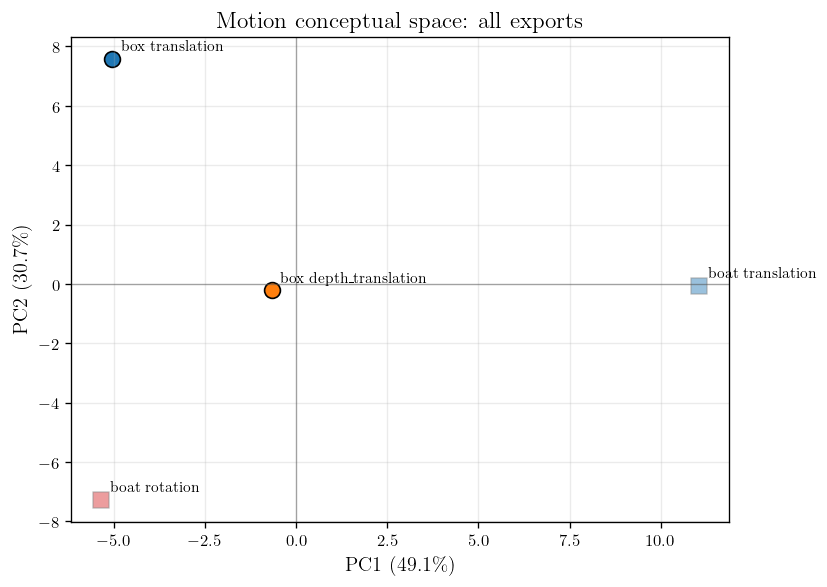

In [17]:
plot_motion_projection(
    memory, proj, explained,
    title='Motion conceptual space: all exports'
)


## Usable pose subset


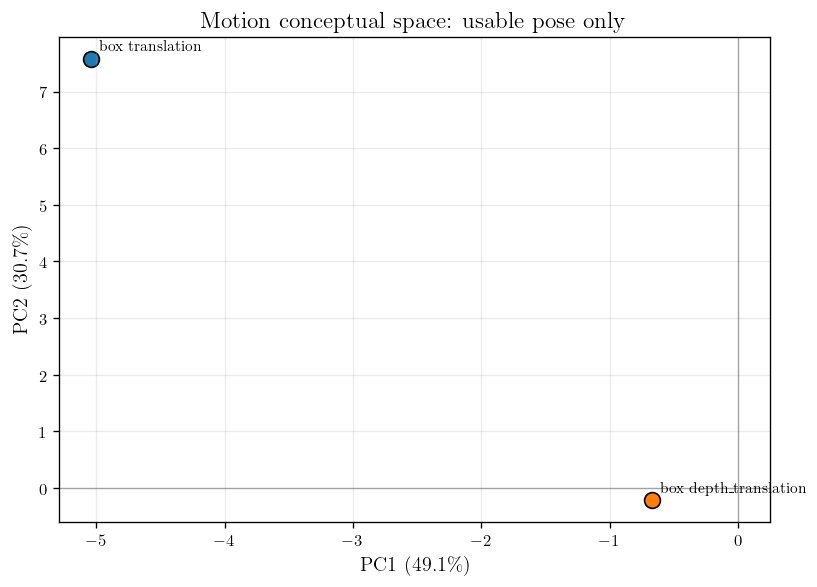

In [18]:
usable_mask = usability == 'yes'

plot_motion_projection(
    memory, proj, explained,
    mask=usable_mask,
    title='Motion conceptual space: usable pose only'
)


## Prototypes


In [19]:
prototypes = memory.prototypes()

for label, proto in prototypes.items():
    print(label, proto)


translation <ConceptPrototype "translation" supported by 2 exemplars in R^90>
depth_translation <ConceptPrototype "depth_translation" supported by 1 exemplars in R^90>
rotation <ConceptPrototype "rotation" supported by 1 exemplars in R^90>


In [20]:
for point in memory:
    print(f"{point.metadata.get('object')} {point.label}")
    for label, proto in prototypes.items():
        dist = memory.space.distance(point, proto)
        print(f'  to {label:<18}: {dist:.3f}')


box translation
  to translation       : 0.812
  to depth_translation : 1.065
  to rotation          : 1.741
box depth_translation
  to translation       : 0.812
  to depth_translation : 0.000
  to rotation          : 1.433
boat translation
  to translation       : 0.812
  to depth_translation : 1.226
  to rotation          : 1.885
boat rotation
  to translation       : 1.623
  to depth_translation : 1.433
  to rotation          : 0.000
